Logistic regression is one of the most popular machine learning algorithms, which comes under the Supervised Learning technique.

It is used for predicting the categorical dependent variable using a given set of independent variables.

Therefore, the outcome must be a categorical or discreate value. It can be either Yes or No, 0 or 1, True or False, etc. but instead of given the exact value as 0 and 1, it gives the probabilistic value which lie between 0 and 1.

logistic regression work on Sigmoid Function

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# binary Classification

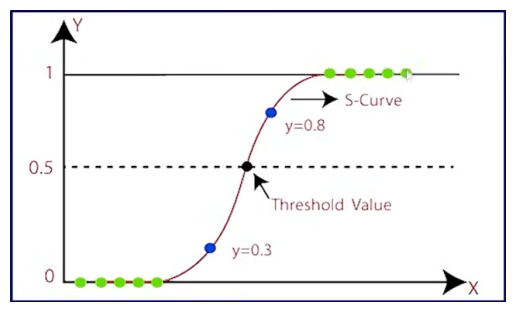

In [2]:
img = mpimg.imread('Image/Logistic.png')
plt.imshow(img)
plt.axis('off')
plt.show()

The Logistic regression equation can be obtained from the Linear Regression equation.
The mathematical steps to get Logistic Regression equations are given below.

$$ y = \frac{1}{1 + e^{-x}} \\[8pt] $$

In [3]:
# y = dependent variable(Bought Product)
# x = independent variable(Salary)
# e = Euler's constant -2.71828

$$ x = m_1 x_1 + m_2 x_2 + \dots + m_n x_n + b $$

In [4]:
# here we can show x follow regresstion so that's why we say it Regression instent of classifier

## Binary Classification With Single Input

In [5]:
df = pd.read_csv('../../Dataset/Social_Network_Ads.csv')
df.drop(columns=['EstimatedSalary'], inplace = True)
df.head()

,Age,Purchased
0,19,0
1,35,0
2,26,0
3,27,0
4,19,0


In [6]:
# Let's do Preidction of is purchased or not based on Age

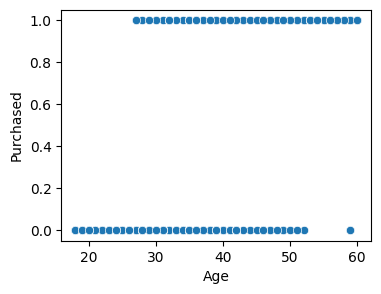

In [7]:
plt.figure(figsize=(4, 3))
sns.scatterplot(x="Age", y="Purchased", data=df)
plt.show()

In [8]:
x = df[['Age']]
y = df['Purchased']

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42) 

In [11]:
from sklearn.linear_model import LogisticRegression

In [12]:
lr = LogisticRegression()
lr.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [13]:
lr.score(x_test, y_test)*100

91.25

In [14]:
# 91 accuraccy is good

In [15]:
lr.coef_

array([[0.17104616]])

In [16]:
lr.intercept_

array([-7.32375024])

In [17]:
lr.predict([[40]])

array([0])

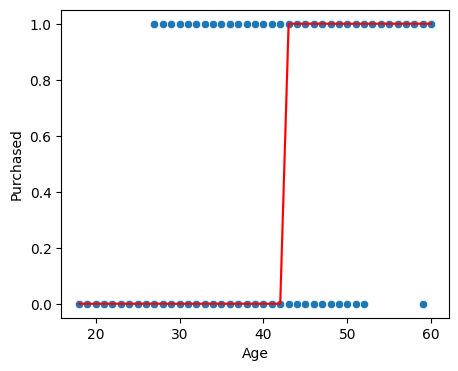

In [18]:
plt.figure(figsize=(5, 4))
sns.scatterplot(x="Age", y="Purchased", data=df)
sns.lineplot(x = "Age", y = lr.predict(x), data = df, c = 'r')
plt.show()

## Binary Classification with Multiple Inputs

In [19]:
df = pd.read_csv('../../Dataset/placement_.csv')
df.head()

,cgpa,resume_score,placed
0,8.14,6.52,1
1,6.17,5.17,0
2,8.27,8.86,1
3,6.88,7.27,1
4,7.52,7.30,1


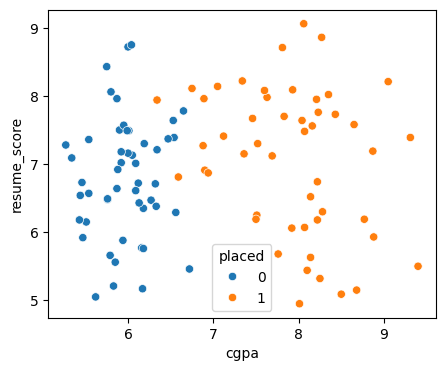

In [20]:
plt.figure(figsize=(5, 4))
sns.scatterplot(x = 'cgpa', y = 'resume_score', data=df, hue='placed')
plt.show()

In [21]:
x = df.iloc[:, :-1]
y = df.iloc[:, -1:]

In [22]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [23]:
from sklearn.linear_model import LogisticRegression

In [24]:
lr = LogisticRegression()
lr.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [25]:
lr.score(x_test, y_test)*100

100.0

In [26]:
# 100% is good Accuraccy

In [27]:
lr.predict([[8.14, 6.52]])

array([1])

In [28]:
lr.coef_

array([[3.03417823, 0.49690768]])

In [29]:
lr.intercept_

array([-24.13435286])

In [30]:
# Ŷ = m1x1 + m2x2 + m3x3 + .... + mnxn + b
(3.0341 * 8.14) + (0.4969 * 6.52) + (-24.1343)

3.803062000000004

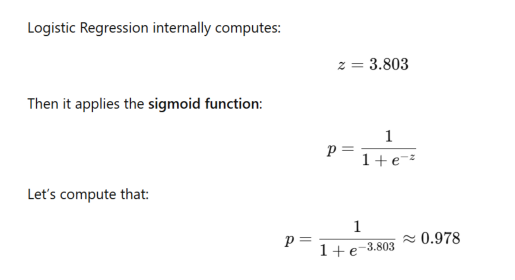

In [31]:
img = mpimg.imread('Image/logistic_algo.png')
plt.imshow(img)
plt.axis('off')
plt.show()

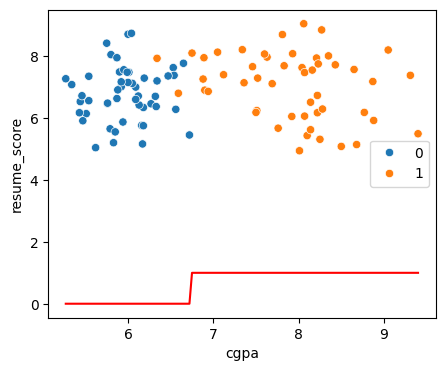

In [32]:
plt.figure(figsize=(5, 4))
sns.scatterplot(x = 'cgpa', y = 'resume_score', data=df, hue='placed')
sns.lineplot(x = 'cgpa', y = lr.predict(x), data=df, c='r')
plt.show()

In [33]:
# we need MLXTEND library to show Proper Prediction line

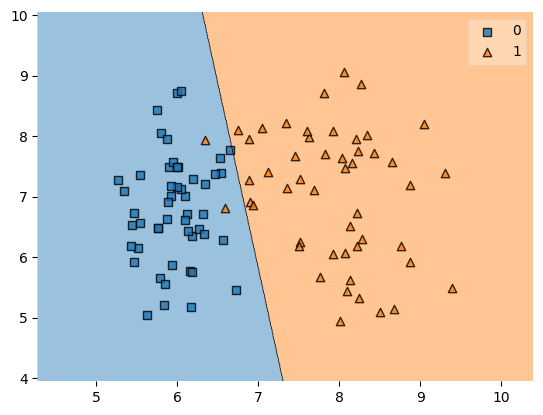

In [34]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(x.to_numpy(), y.to_numpy().flatten(), clf=lr)
plt.show()

## Binary Classification with Polynomial Inputs

In [35]:
# if our Data mix format than we are use Polynomial from Preprocessing and then Predicat
# Because Polynomial give us Good Acuureccy than normal
# in that below algo x = ŷ

$$ y = \frac{1}{1 + e^{-x}} $$
$$ \hat{y} = m_1 x + m_2 x^2 + m_3 x^3 $$


In [36]:
np.random.seed(42)   # for reproducibility

n_samples = 1000       # number of rows

x = np.random.uniform(-5, 5, n_samples)
y = np.random.uniform(0, 5, n_samples)
result = np.random.randint(0, 2, n_samples)

BCP = pd.DataFrame({
    'x': x,
    'y': y,
    'result': result
})

BCP

,x,y,result
0,-1.254599,0.925665,1
1,4.507143,2.709505,0
2,2.319939,4.364729,0
3,0.986585,3.661124,0
4,-3.439814,4.032806,1
...,...,...,...
995,-4.084179,3.284776,0
996,4.173136,4.783073,1
997,-3.631814,0.344790,0
998,4.502374,0.285274,1


In [37]:
BCP.head()

,x,y,result
0,-1.254599,0.925665,1
1,4.507143,2.709505,0
2,2.319939,4.364729,0
3,0.986585,3.661124,0
4,-3.439814,4.032806,1


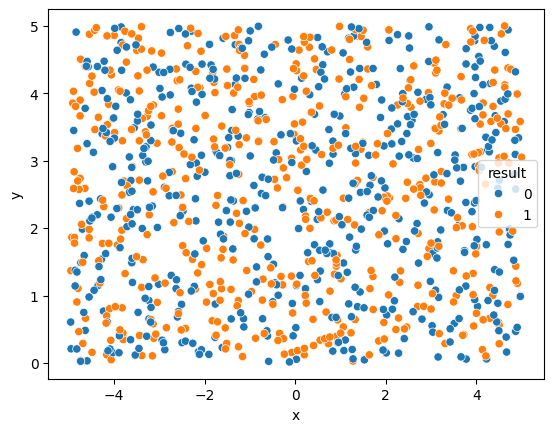

In [38]:
sns.scatterplot(x = 'x', y='y', data=BCP, hue='result')
plt.show()

## First Do without Binary Polynomial

In [39]:
x = BCP.iloc[:, :-1]
y = BCP.iloc[:, -1:]
x.head()

,x,y
0,-1.254599,0.925665
1,4.507143,2.709505
2,2.319939,4.364729
3,0.986585,3.661124
4,-3.439814,4.032806


In [40]:
from sklearn.model_selection import train_test_split

In [41]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [42]:
from sklearn.linear_model import LogisticRegression

In [43]:
LR = LogisticRegression()

In [44]:
LR.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [45]:
LR.score(x_test, y_test)*100

45.0

In [46]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

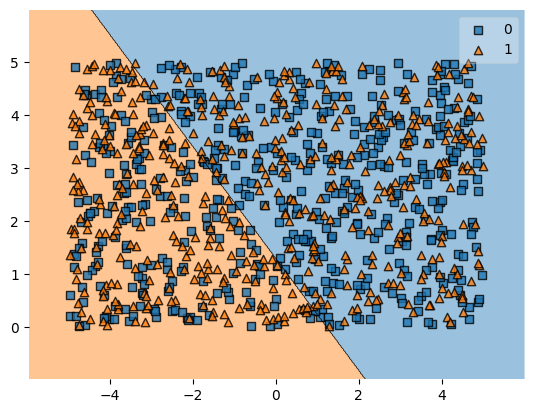

In [47]:
plot_decision_regions(x.to_numpy(), y.to_numpy().flatten(), clf=LR)

## With Binary Polynomial

In [48]:
x = BCP.iloc[:, :-1]
y = BCP.iloc[:, -1:]
x.head()

,x,y
0,-1.254599,0.925665
1,4.507143,2.709505
2,2.319939,4.364729
3,0.986585,3.661124
4,-3.439814,4.032806


In [49]:
from sklearn.preprocessing import PolynomialFeatures

In [50]:
pf = PolynomialFeatures(degree=8)

In [51]:
pf.fit(x, y)
x = pd.DataFrame(pf.transform(x))
x.head()

,0,1,2,3,4,5,6,7,8,9,...,35,36,37,38,39,40,41,42,43,44
0,1.0,-1.254599,0.925665,1.574018,-1.161338,0.856855,-1.974761,1.457013,-1.075009,0.793160,...,0.582339,6.138171,-4.528848,3.341462,-2.465389,1.819006,-1.342094,0.990220,-0.730602,0.539050
1,1.0,4.507143,2.709505,20.314339,12.212125,7.341416,91.559630,55.041797,33.088812,19.891601,...,1072.085451,170298.470737,102376.273969,61544.307629,36997.847789,22241.549117,13370.683343,8037.892150,4832.042503,2904.820607
2,1.0,2.319939,4.364729,5.382119,10.125907,19.050861,12.486190,23.491491,44.196843,83.151848,...,30178.740722,839.098901,1578.678922,2970.123229,5587.983644,10513.220765,19779.551606,37213.207110,70012.850191,131722.030227
3,1.0,0.986585,3.661124,0.973350,3.612010,13.403832,0.960292,3.563554,13.224018,49.073097,...,8816.605886,0.897585,3.330854,12.360488,45.868619,170.214171,631.648929,2343.990327,8698.329724,32278.691215
4,1.0,-3.439814,4.032806,11.832318,-13.872100,16.263522,-40.700967,47.717438,-55.943485,65.587625,...,17348.068067,19601.046971,-22980.086718,26941.641758,-31586.132356,37031.290303,-43415.143268,50899.513616,-59674.120395,69961.388468


In [52]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [53]:
lr = LogisticRegression()
lr.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [54]:
lr.score(x_test, y_test)*100

47.5

# MultiClass Classification

$$
\text{Class Labels} \rightarrow
\begin{bmatrix}
\text{Cat} \\
\text{Dog} \\
\text{Cow}
\end{bmatrix}
\quad \Longrightarrow \quad
\begin{bmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & 1
\end{bmatrix}
$$


In [55]:
MClass = pd.read_csv('../../Dataset/iris.csv')
MClass.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [56]:
MClass['species'].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

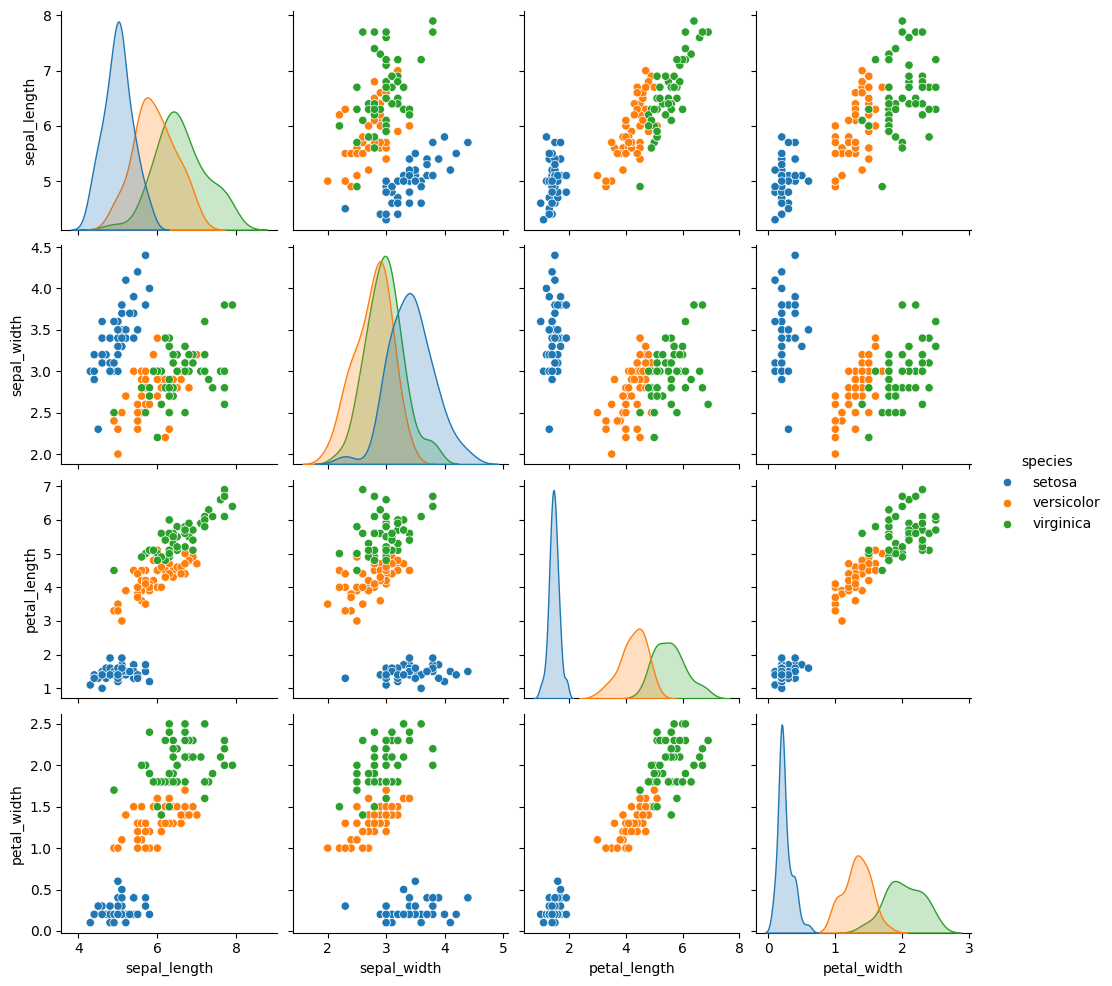

In [57]:
sns.pairplot(data=MClass, hue='species')

In [58]:
x = MClass.iloc[:, :-1]
y = MClass.iloc[:, -1:]
x.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [59]:
from sklearn.model_selection import train_test_split

In [60]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [61]:
from sklearn.linear_model import LogisticRegression

## Normal

In [62]:
lrn = LogisticRegression()
lrn.fit(x_train, y_train)
lrn.score(x_test, y_test)*100

100.0

## OVR = One-Vs-Rest

In [63]:
# OVA (One-Vs-All) is a technique to use logistic regression for multiclass classification.
# Logistic Regression itself is binary (only 0 or 1), so it cannot directly classify many classes.
# OVA fixes this by creating multiple binary models.

# Suppose we have 3 classes: Cat, Dog, Cow
# OVA creates 1 model per class:

# Model 1: Cat vs (Dog + Cow)
# Model 2: Dog vs (Cat + Cow)
# Model 3: Cow vs (Cat + Dog)

# For each model:
#   - The selected class is labeled as 1 (positive class)
#   - All other classes are labeled as 0 (negative class)

# During prediction:
#   - Each model returns a probability that the input belongs to its class.
#   - Example:
#         Model 1 says probability Cat = 0.65
#         Model 2 says probability Dog = 0.20
#         Model 3 says probability Cow = 0.15
#   - The final prediction is the class with highest probability → Cat

# Summary:
#   - Train N binary classifiers for N classes.
#   - Pick the class with highest probability at prediction time.
#   - This is how logistic regression handles multiclass through OVA.


In [64]:
lro = LogisticRegression(multi_class='ovr')
lro.fit(x_train, y_train)
lro.score(x_test, y_test)*100

96.66666666666667

## Multinomial

In [65]:
# Multinomial Logistic Regression (also called Softmax Regression)
# is another way to perform multiclass classification using Logistic Regression.

# Unlike OVA (One-Vs-All), multinomial does NOT train one model per class.
# Instead, it trains ONE single model for ALL classes together.

# Suppose we have 3 classes: Cat, Dog, Cow

# Multinomial logistic regression calculates a score for each class:
#       score_cat = m1*x + c1
#       score_dog = m2*x + c2
#       score_cow = m3*x + c3

# Then it applies the Softmax function to convert scores into probabilities:
#       P(cat) = exp(score_cat) / (exp(score_cat) + exp(score_dog) + exp(score_cow))
#       P(dog) = exp(score_dog) / (exp(score_cat) + exp(score_dog) + exp(score_cow))
#       P(cow) = exp(score_cow) / (exp(score_cat) + exp(score_dog) + exp(score_cow))

# During prediction:
#   The class with the highest probability is selected.

# Example:
#   P(cat) = 0.10
#   P(dog) = 0.30
#   P(cow) = 0.60
#   Final prediction → Cow

# Summary:
#   - Multinomial logistic regression uses ONE model for all classes.
#   - Probabilities are calculated using the Softmax function.
#   - The class with the highest Softmax probability is the output.


In [66]:
lrm = LogisticRegression(multi_class='multinomial')
lrm.fit(x_train, y_train)
lrm.score(x_test, y_test)*100

100.0

## OVO = One-Vs-One

In [67]:
# OVO = One-Vs-One multiclass classification technique
# It is used when the algorithm can classify only two classes at a time (binary classifier)

# In OVO, instead of comparing one class vs all others,
# we compare classes in pairs.

# Example: Suppose we have 3 classes -> A, B, C

# OVA method would build: A vs (B,C), B vs (A,C), C vs (A,B)
# BUT OVO builds:
# 1) A vs B
# 2) A vs C
# 3) B vs C

# So for K total classes, OVO builds K * (K - 1) / 2 models.

# During prediction time:
# Each binary classifier predicts its winning class.
# All classifiers vote, and the class with maximum total votes becomes the final output.

# Example prediction:
# Classifier (A vs B) -> A
# Classifier (A vs C) -> C
# Classifier (B vs C) -> C

# Votes result:
# A = 1 vote
# B = 0 votes
# C = 2 votes  ---> FINAL PREDICTED CLASS

# Summary:
# ✔ OVO is highly accurate because each model learns to distinguish only 2 classes.
# ✔ Best suited for SVM / non-linear classifiers.
# ❌ Requires many models when total classes are large (slow training & prediction).


In [68]:
from sklearn.svm import SVC

svc = SVC(decision_function_shape='ovo')
svc.fit(x_train, y_train)
svc.score(x_test, y_test)*100

100.0

In [69]:
print("Normal",lrn.score(x_test, y_test)*100)
print("OVR - One vs Rest",lro.score(x_test, y_test)*100)
print("Multinomial",lrm.score(x_test, y_test)*100)
print("SVC/OVO - One Vs One",svc.score(x_test, y_test)*100)

Normal 100.0
OVR - One vs Rest 96.66666666666667
Multinomial 100.0
SVC/OVO - One Vs One 100.0


# Normal Most of time Give Best Score 
# Normal use Auto
# Because Normal Identify binary classification or multiclass classification then fit model
# Normal means not write anything